# ML4PAY Hackathon ITMO x AVITO
*Команда: Хог 2.6*

In [1]:
import polars as pl
import numpy as np

import random, gc, os
from pathlib import Path

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

from sklearn.metrics import classification_report, f1_score, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:
RND = 67

def set_seed(seed):
    random.seed(seed)
    os.environ['PYHASHSEED'] = str(seed)
    np.random.seed(seed)

set_seed(RND)

In [3]:
train_dir  = Path("/kaggle/input/datasets/tensonn/probablyitswork/final_dataset.parquet")
test_dir   = Path("/kaggle/input/datasets/tensonn/test-df/train_merged.parquet")
coords_dir = Path("/kaggle/input/datasets/omnillos/cities/cities_geocoded.csv")
out_dir    = Path("submission.csv")

# 1) Обработка данных

### Делим данные на три части по временным периодам:
- 2025.10.01 - 2025.10.10 - Train 
- 2025.10.11 - 2025.10.20 - Test

In [4]:
from datetime import date

TRAIN_END_DATE = date(2025, 10, 1)
TEST_START_CREATE_DATE = date(2025, 10, 11)
TEST_END_CREATE_DATE = date(2025, 10, 21)

In [5]:
train_lf = pl.scan_parquet(train_dir)
test_lf  = pl.scan_parquet(test_dir)

def f(name, df):
    df = df.with_columns([
        pl.col("order_create_date")
        .cast(pl.Utf8)
        .str.to_datetime(strict=False),
    
        pl.col("registrationtime")
        .cast(pl.Utf8)
        .str.to_datetime(strict=False),
    
        pl.col("starttime")
        .cast(pl.Utf8)
        .str.to_datetime(strict=False),
    
        pl.col("firstlistingdate")
        .cast(pl.Utf8)
        .str.to_datetime(strict=False),
    
        pl.col("created_txtime")
        .cast(pl.Utf8)
        .str.to_datetime(strict=False),
    ])
    if name == 'train':
        df = df.filter(pl.col('order_create_date').dt.date() < pl.lit(TRAIN_END_DATE))
        
    else: df = df.filter(
        (pl.col("order_create_date").dt.date() >= pl.lit(TEST_START_CREATE_DATE)) &
        (pl.col("order_create_date").dt.date() < pl.lit(TEST_END_CREATE_DATE))
    )
    return df

train_lf = f('train', train_lf)
test_lf   = f('', test_lf)

In [6]:
train_lf = train_lf.with_columns(
    pl.col("gender").fill_null("female")
)

test_lf = test_lf.with_columns(
    pl.col("gender").fill_null("female")
)

Обработка временных признаков

In [7]:
DATE_TIME_COLS = [
    "order_create_date",
    "registrationtime",
    "starttime",
    "firstlistingdate",
    "created_txtime",
]

def fix_dates(df):
    return df.with_columns([
        
        (pl.col(col)
         .cast(pl.Utf8)
         .str.replace("T", " ")
         .str.slice(0, 19)
         .str.strptime(
                pl.Datetime,
                "%Y-%m-%d %H:%M:%S",
                strict=False
            ).alias(col))
        
        for col in DATE_TIME_COLS
        if col in df.collect_schema().names()
    ])

In [8]:
train_lf = fix_dates(train_lf)
test_lf   = fix_dates(test_lf)

### Заполняем пропуски модой

TRAIN + TEST separately

In [9]:
fill_mode_cols = [
    "registrationtime", "starttime",
    "firstlistingdate", "platform_id",
    "payment_method", "isblocked",
    "iscompany", "category_name"
]

In [10]:
for col in fill_mode_cols:
    col_mode_train = (
        train_lf
        .group_by(col)
        .len()
        .filter(pl.col(col).is_not_null())
        .sort("len", descending=True)
        .select(col)
        .collect()[0,0]
    )
    col_mode_test = (
        test_lf
        .group_by(col)
        .len()
        .filter(pl.col(col).is_not_null())
        .sort("len", descending=True)
        .select(col)
        .collect()[0,0]
    )

    train_lf = train_lf.with_columns(pl.col(col).fill_null(col_mode_train))
    test_lf  = test_lf.with_columns(pl.col(col).fill_null(col_mode_test))
    

Amount будет заполнять медианой внутри каждого categroy name

In [11]:
# amount

def amount_fill(df):
    
    category_amount_median = (
        df
        .filter(pl.col("amount") != -1)
        .group_by("category_name")
        .agg(
            pl.col("amount").median().alias("category_amount_median")
        )
    )

    df = (
        train_lf
        .join(category_amount_median, on="category_name", how="left")
        .with_columns(
            pl.when(
                pl.col("amount").is_null() |
                (pl.col("amount") == -1)
            )
            .then(pl.col("category_amount_median"))
            .otherwise(pl.col("amount"))
            .alias("amount")
        )
        .drop("category_amount_median")
    )
    
    return df

train_lf = amount_fill(train_lf)
test_lf   = amount_fill(test_lf)

In [ ]:
train_eda = train_lf.collect().to_pandas()




# 2) Генерация дополнительных признаков

**Основные доп признаки:**
1) order_weekday - день недели заказа
2) buyer_age - как быстро был создан заказ относительно регистрации покупателя на платформе
3) seller_activity_age_days - общее время нахождения продавца на платформе
4) order_price_median - медина по цене заказа 
5) microcat_median_price - медианная цена по микрокатегории 

In [12]:
schema_cols = set(train_lf.collect_schema().names())

for i in schema_cols:
    print(i)

is_train
platform_id
seller_terminal
item_id
order_create_date
payment_method
buyer_terminal
city
registrationtime
buyer_id
order_price
user_id
delivery_service
deliveryorder_id
title
seller_id
created_txtime
isblocked
microcat_name
gender
iscompany
starttime
category_name
firstlistingdate
amount
is_return


In [13]:
def get_median(lf, col):
    return lf.select(pl.col(col).median()).collect().item()

def clean_base_frame(lf: pl.LazyFrame, order_price_median: float, microcat_stats: pl.LazyFrame) -> pl.LazyFrame:

    local_cols = set(lf.collect_schema().names())
    exprs = []

    # weekday
    exprs.append(
        pl.col("order_create_date")
        .dt.weekday()
        .cast(pl.Int8)
        .alias("order_weekday")
    )

    # buyer age
    days_diff = ( pl.col("order_create_date") - pl.col("registrationtime") ).dt.total_days()
    
    exprs.append(
        pl.when(days_diff < 0)
        .then(0)
        .otherwise(days_diff)
        .fill_null(0)
        .cast(pl.Int32)
        .alias("buyer_account_age_days")
    )
    
    # seller activity age
    seller_days_diff = ( pl.col("firstlistingdate") - pl.col("registrationtime") ).dt.total_days()

    exprs.append(
        pl.when(seller_days_diff < 0)
        .then(0)
        .otherwise(seller_days_diff)
        .fill_null(0)
        .cast(pl.Int32)
        .alias("seller_activity_age_days")
    )

    # order price
    price_filled = (pl.col("order_price").fill_null(order_price_median))

    exprs.append(
        pl.when(price_filled < 0)
        .then(0)
        .otherwise(price_filled)
        .alias("order_price")
    )

    return lf.with_columns(exprs)

In [14]:
order_price_median = get_median(train_lf, "order_price")

microcat_stats = train_lf.group_by("microcat_name").agg(
    pl.col("order_price").median().alias("microcat_median_price")
)


train_lf = clean_base_frame(
    train_lf,
    order_price_median,
    microcat_stats
)

test_lf = clean_base_frame(
    test_lf,
    order_price_median,
    microcat_stats
)

**Дополнительные признаки на основе координат городов (собранные данные через geopy)**

In [15]:
coords_df = pl.read_csv(coords_dir)
coords_df = coords_df.drop(['clean_city', 'address', 'matched_query'])
coords_df = coords_df.filter(
    pl.col('latitude').is_not_null() & pl.col('longitude').is_not_null()
)

coords_df.head(5)

city,latitude,longitude
str,f64,f64
"""Рудничный""",59.615108,52.47382
"""Семибратово""",57.298833,39.538683
"""Каликино""",56.203262,42.081837
"""Посевная""",54.300575,83.329704
"""Судак""",62.037577,32.992048


**Расстояние до центра кластера которому принадлежит город**

Распределим города на кластеры с помощью KMeans, а затем будет добовлять расстояние до центра класетра как дополнительный признак  

In [16]:
n_clusters = 50

coords_pd = coords_df.select(['city', 'longitude', 'latitude']).to_pandas()
X_k = coords_pd[['longitude', 'latitude']].to_numpy()

In [17]:
from sklearn.cluster import KMeans

knn = KMeans(n_clusters = n_clusters,random_state = RND)

coords_pd['geo_cluster'] = knn.fit_predict(X_k)

centers = knn.cluster_centers_

In [18]:
# Расчитаем расстояние до центров через haversine

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))
    

In [19]:
coords_pd["geo_cluster_center_lat"] = coords_pd["geo_cluster"].map(lambda c: centers[c, 0])
coords_pd["geo_cluster_center_lon"] = coords_pd["geo_cluster"].map(lambda c: centers[c, 1])

coords_pd["geo_dist_to_cluster_center_km"] = haversine(
    coords_pd["latitude"].to_numpy(),
    coords_pd["longitude"].to_numpy(),
    coords_pd["geo_cluster_center_lat"].to_numpy(),
    coords_pd["geo_cluster_center_lon"].to_numpy()
)

coords_feat = pl.from_pandas(
    coords_pd[[
        "city",
        "geo_cluster",
        "geo_dist_to_cluster_center_km"
    ]]
)

coords_feat.head(5)

city,geo_cluster,geo_dist_to_cluster_center_km
str,i32,f64
"""Рудничный""",49,1091.971197
"""Семибратово""",6,2421.722286
"""Каликино""",10,1809.984545
"""Посевная""",2,3164.824875
"""Судак""",9,4001.263731


In [20]:
train_lf = train_lf.join(coords_feat.lazy(), on='city', how='left')
test_lf  = test_lf.join(coords_feat.lazy(),  on='city', how='left')

In [21]:
train_lf = train_lf.with_columns([
    pl.col("geo_cluster").fill_null(-1).cast(pl.Int32),
    pl.col("geo_dist_to_cluster_center_km").fill_null(-1.0),
])

test_lf = test_lf.with_columns([
    pl.col("geo_cluster").fill_null(-1).cast(pl.Int32),
    pl.col("geo_dist_to_cluster_center_km").fill_null(-1.0),
])

In [22]:
train_lf = train_lf.drop("city")
test_lf = test_lf.drop("city")

In [23]:
DROP_COLS = [
    "item_id",
    "buyer_id",
    "seller_id",
    "user_id",
    "firstlistingdate",
    "buyer_terminal", 
    "seller_terminal", 
    "registrationtime",
    "starttime",
    "created_txtime",
    "is_train",
    "deliveryorder_id",
    "platform_id",
]

train_lf = train_lf.drop(DROP_COLS)
test_lf  = test_lf.drop(DROP_COLS)

# 3) Обучение модели

In [24]:
# подготовка данных

df_train = train_lf.collect().to_pandas()
target_col = 'is_return'

In [25]:
y = df_train[target_col].astype(int).values
X = df_train.drop(columns=[target_col])

In [26]:
import pandas as pd

for col in X.columns:
    if pd.api.types.is_datetime64_any_dtype(X[col]):
        X[col] = X[col].astype("int64") // 10**9

bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    X[col] = X[col].astype(int)

In [27]:
X

,order_create_date,delivery_service,order_price,title,microcat_name,category_name,iscompany,isblocked,gender,payment_method,amount,order_weekday,buyer_account_age_days,seller_activity_age_days,geo_cluster,geo_dist_to_cluster_center_km
0,1759190,pochta,800.0,Автолюлька 0+ состояние идеальное,Автолюльки,Личные вещи,0,0,female,Wallet,913.0,2,3473,0,15,780.485039
1,1753315,yandex-market-pvz,2490.0,Зип худи Polo Ralph Lauren премиум,Кофты и футболки,Личные вещи,1,0,female,SBP,2709.0,4,3277,0,45,2392.309388
2,1753228,avito-pvz,2500.0,Казаки бежевые 37,Полусапоги,Личные вещи,0,0,female,SBP,2664.0,3,2009,478,46,977.350659
3,1752278,avito-pvz,1287.0,Сумка мужская,Сумки,Личные вещи,1,0,female,Пластиковая карта,1353.0,6,2268,0,9,3944.725672
4,1752710,five-post,6750.0,Комплект фильтров на 2.3 Ford Mustang 6,Двигатель,Транспорт,0,0,male,SBP,7239.0,4,1995,0,47,3374.451712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35023172,1758240,five-post,280.0,Насадка для Karcher,Запчасти,Для дома и дачи,0,0,female,SBP,1447.0,5,1949,0,30,764.094479
35023173,1758240,five-post,280.0,Насадка для Karcher,Запчасти,Для дома и дачи,0,0,female,SBP,1447.0,5,1949,0,30,764.094479
35023174,1758240,five-post,280.0,Насадка для Karcher,Запчасти,Для дома и дачи,0,0,female,SBP,1447.0,5,1949,0,30,764.094479
35023175,1757289,pochta,17500.0,"vivo IQOO Neo 10, 12/256 ГБ, 2 SIM",Мобильные телефоны,Электроника,0,0,female,SBP,2290.0,1,1938,0,0,2107.650138


In [28]:
cat_cols = ['delivery_service', 'category_name', 'gender', 'payment_method']
text_cols = ["title", "microcat_name",]

for col in cat_cols:
    X[col] = X[col].astype('category').cat.add_categories('MISSING')
    X[col] = X[col].fillna('MISSING')

for col in text_cols:
    X[col] = X[col].fillna('MISSING').astype(str)

In [29]:
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score

n_folds = 3
oof_pred = np.zeros(len(X), dtype=float)
fold_pr_auc = []

skf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = RND)
bar = tqdm(skf.split(X, y), total = n_folds)

for fold, (tr_idx, va_idx) in enumerate(bar):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[va_idx], y[va_idx]

    params = {
        'random_seed': RND + fold,
        'learning_rate': 0.05,
        'auto_class_weights': "SqrtBalanced",
        'eval_metric': 'AUC',
        'task_type': 'GPU',
        'l2_leaf_reg': 5,
        'iterations': 2000, 
        'depth': 8,
        'early_stopping_rounds': 200,
    }

    print(params)
    
    tr_pool = Pool(X_tr, y_tr, cat_features = cat_cols, text_features = text_cols)
    va_pool = Pool(X_va, y_va, cat_features = cat_cols, text_features = text_cols)

    model = CatBoostClassifier(**params)
    model.fit(tr_pool, eval_set = va_pool, verbose = 200)

    va_pred = model.predict_proba(X_va)[:, 1]
    oof_pred[va_idx] = va_pred

    pr_auc = precision_recall_curve(y_va, va_pred)
    fold_pr_auc.append(pr_auc)
    bar.set_postfix(PR_AUC=f'{average_precision_score(y_va, va_pred):.4f}')

  0%|          | 0/3 [00:00<?, ?it/s]

{'random_seed': 67, 'learning_rate': 0.05, 'auto_class_weights': 'SqrtBalanced', 'eval_metric': 'AUC', 'task_type': 'GPU', 'l2_leaf_reg': 5, 'iterations': 2000, 'depth': 8, 'early_stopping_rounds': 200}


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6764427	best: 0.6764427 (0)	total: 6.79s	remaining: 3h 46m 8s
200:	test: 0.7418603	best: 0.7418603 (200)	total: 1m 5s	remaining: 9m 50s
400:	test: 0.7445874	best: 0.7445874 (400)	total: 1m 49s	remaining: 7m 18s
600:	test: 0.7461278	best: 0.7461278 (600)	total: 2m 32s	remaining: 5m 53s
800:	test: 0.7472785	best: 0.7472785 (800)	total: 3m 14s	remaining: 4m 50s
1000:	test: 0.7479982	best: 0.7479982 (1000)	total: 3m 55s	remaining: 3m 55s
1200:	test: 0.7486007	best: 0.7486007 (1200)	total: 4m 37s	remaining: 3m 4s
1400:	test: 0.7491484	best: 0.7491484 (1400)	total: 5m 19s	remaining: 2m 16s
1600:	test: 0.7495893	best: 0.7495893 (1600)	total: 6m 1s	remaining: 1m 30s
1800:	test: 0.7499600	best: 0.7499600 (1800)	total: 6m 43s	remaining: 44.5s
1999:	test: 0.7503756	best: 0.7503756 (1999)	total: 7m 24s	remaining: 0us
bestTest = 0.7503755689
bestIteration = 1999
{'random_seed': 68, 'learning_rate': 0.05, 'auto_class_weights': 'SqrtBalanced', 'eval_metric': 'AUC', 'task_type': 'GPU', 'l2_

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6771133	best: 0.6771133 (0)	total: 377ms	remaining: 12m 33s
200:	test: 0.7423241	best: 0.7423241 (200)	total: 59.8s	remaining: 8m 55s
400:	test: 0.7447766	best: 0.7447766 (400)	total: 1m 42s	remaining: 6m 48s
600:	test: 0.7462509	best: 0.7462509 (600)	total: 2m 25s	remaining: 5m 38s
800:	test: 0.7471680	best: 0.7471680 (800)	total: 3m 7s	remaining: 4m 41s
1000:	test: 0.7480507	best: 0.7480507 (1000)	total: 3m 50s	remaining: 3m 49s
1200:	test: 0.7486473	best: 0.7486473 (1200)	total: 4m 32s	remaining: 3m 1s
1400:	test: 0.7491126	best: 0.7491126 (1400)	total: 5m 13s	remaining: 2m 14s
1600:	test: 0.7496025	best: 0.7496025 (1600)	total: 5m 55s	remaining: 1m 28s
1800:	test: 0.7500217	best: 0.7500217 (1800)	total: 6m 38s	remaining: 44s
1999:	test: 0.7504159	best: 0.7504159 (1999)	total: 7m 19s	remaining: 0us
bestTest = 0.7504159212
bestIteration = 1999
{'random_seed': 69, 'learning_rate': 0.05, 'auto_class_weights': 'SqrtBalanced', 'eval_metric': 'AUC', 'task_type': 'GPU', 'l2_leaf

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6773212	best: 0.6773212 (0)	total: 292ms	remaining: 9m 44s
200:	test: 0.7416256	best: 0.7416256 (200)	total: 58.4s	remaining: 8m 42s
400:	test: 0.7446565	best: 0.7446565 (400)	total: 1m 42s	remaining: 6m 48s
600:	test: 0.7460732	best: 0.7460732 (600)	total: 2m 24s	remaining: 5m 37s
800:	test: 0.7471511	best: 0.7471511 (800)	total: 3m 7s	remaining: 4m 41s
1000:	test: 0.7479896	best: 0.7479896 (1000)	total: 3m 49s	remaining: 3m 49s
1200:	test: 0.7485378	best: 0.7485378 (1200)	total: 4m 30s	remaining: 3m
1400:	test: 0.7490542	best: 0.7490542 (1400)	total: 5m 12s	remaining: 2m 13s
1600:	test: 0.7496169	best: 0.7496169 (1600)	total: 5m 54s	remaining: 1m 28s
1800:	test: 0.7499599	best: 0.7499599 (1800)	total: 6m 36s	remaining: 43.8s
1999:	test: 0.7503020	best: 0.7503020 (1999)	total: 7m 17s	remaining: 0us
bestTest = 0.7503019571
bestIteration = 1999


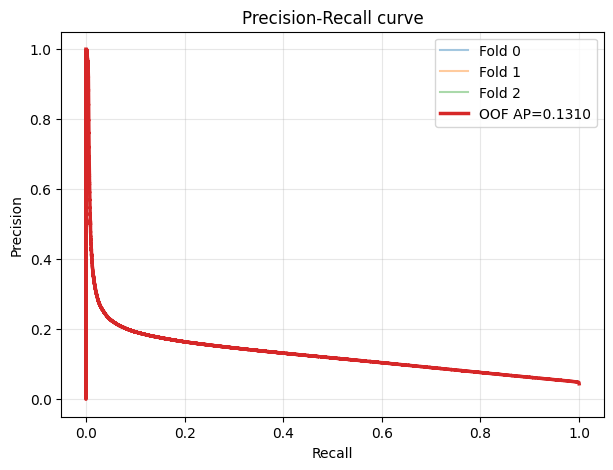

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for fold, (precision, recall, _) in enumerate(fold_pr_auc):
    ap = average_precision_score(y_va, va_pred)
    plt.plot(recall, precision, alpha=0.4, label=f"Fold {fold}")

precision, recall, _ = precision_recall_curve(y, oof_pred)
ap = average_precision_score(y, oof_pred)

plt.plot(recall, precision, linewidth=2.5, label=f"OOF AP={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


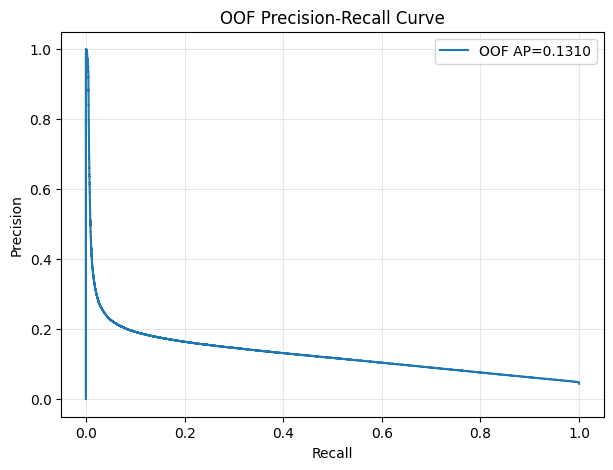

In [80]:
precision, recall, _ = precision_recall_curve(y, oof_pred)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"OOF AP={average_precision_score(y, oof_pred):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("OOF Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [81]:
oof_pr_auc = average_precision_score(y, oof_pred)

precision, recall, thresholds = precision_recall_curve(y, oof_pred)
f1_vals = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = np.argmax(f1_vals)
best_threshold = thresholds[max(best_idx - 1, 0)] if len(thresholds) > 0 else 0.5

y_pred = (oof_pred >= best_threshold).astype(int)

In [86]:
from sklearn.metrics import precision_score, recall_score

print("=== OOF RESULTS ===")

print(f"OOF PR AUC: {oof_pr_auc:.6f}")
print(f"Best threshold: {best_threshold:.6f}")
print(f"Precision: {precision_score(y, y_pred, zero_division=0):.6f}")
print(f"Recall:    {recall_score(y, y_pred, zero_division=0):.6f}")
print(f"F1:        {f1_score(y, y_pred, zero_division=0):.6f}")

=== OOF RESULTS ===
OOF PR AUC: 0.130966
Best threshold: 0.335144
Precision: 0.137791
Recall:    0.357806
F1:        0.198962


In [89]:
params = {
    'random_seed': RND,
    'learning_rate': 0.05,
    'auto_class_weights': "SqrtBalanced",
    'task_type': 'GPU',
    'l2_leaf_reg': 5,
    'iterations': 2000, 
    'depth': 8,
    'early_stopping_rounds': 200,
}


final_model = CatBoostClassifier(**params)
final_model.fit(
    X, 
    y, 
    cat_features=cat_cols,
    text_features=text_cols,
    verbose=200
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 435ms	remaining: 14m 29s
200:	total: 1m 31s	remaining: 13m 36s
400:	total: 2m 37s	remaining: 10m 27s
600:	total: 3m 40s	remaining: 8m 34s
800:	total: 4m 43s	remaining: 7m 4s
1000:	total: 5m 46s	remaining: 5m 45s
1200:	total: 6m 49s	remaining: 4m 32s
1400:	total: 7m 53s	remaining: 3m 22s
1600:	total: 8m 56s	remaining: 2m 13s
1800:	total: 10m	remaining: 1m 6s
1999:	total: 11m 3s	remaining: 0us


CatBoostClassifier(auto_class_weights='SqrtBalanced', depth=8, early_stopping_rounds=200, eval_metric='AUC', iterations=2000, l2_leaf_reg=5, learning_rate=0.05, random_seed=67, task_type='GPU')

In [90]:
final_model.save_model('final_model.cbm')

In [94]:
help(final_model.get_feature_importance)

Help on method get_feature_importance in module catboost.core:

get_feature_importance(data=None, type=<EFstrType.FeatureImportance: 2>, prettified=False, thread_count=-1, verbose=False, fstr_type=None, shap_mode='Auto', model_output='Raw', interaction_indices=None, shap_calc_type='Regular', reference_data=None, sage_n_samples=128, sage_batch_size=512, sage_detect_convergence=True, log_cout=None, log_cerr=None) method of catboost.core.CatBoostClassifier instance
    Parameters
    ----------
    data :
        Data to get feature importance.
        If type in ('LossFunctionChange', 'ShapValues', 'ShapInteractionValues') data must of Pool type.
            For every object in this dataset feature importances will be calculated.
        if type == 'SageValues' data must of Pool type.
            For every feature in this dataset importance will be calculated.
        If type == 'PredictionValuesChange', data is None or a dataset of Pool type
            Dataset specification is needed o

In [ ]:
importances = final_model.get_feature_importance(Pool(X, y, cat_features=cat_cols, text_features=text_cols), type='FeatureImportance')

In [ ]:
importances

# 4) Предсказание

In [91]:
test_df = test_lf.collect().to_pandas()

submission_item_ids = test_item_ids.reset_index(drop=True)
X_test = test_df.drop(columns=["is_return"], errors="ignore").copy()

for col in X_test.columns:
    if pd.api.types.is_datetime64_any_dtype(X_test[col]):
        X_test[col] = X_test[col].astype("int64") // 10**9

bool_cols = X_test.select_dtypes(include=["bool"]).columns.tolist()

for col in bool_cols:
    X_test[col] = X_test[col].astype(int)


for col in cat_cols:
    X[col] = X[col].astype('category').cat.add_categroy('MISSING')
    X[col] = X[col].fillna('MISSING')

for col in text_cols:
    X[col] = X[col].fillna('MISSING').astype(str)

NameError: name 'test_item_ids' is not defined

In [ ]:
test_proba = final_model.predict_proba(X_test)[:, 1]

test_pred = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    "item_id": submission_item_ids,
    "is_return": test_pred,
})

submission.to_csv(
    out_dir,
    index=False
)

submission.head()